In [1]:
import os
current_path  = os.getcwd()
if current_path == "c:\\Users\\bryan\\OneDrive - Université Libre de Bruxelles\\Master 2 Ingénieur Civile\\Master Thesis\\Master-Thesis-Bryan-ML\\MSc_Bryan_Rincon":
    os.chdir("..")
    print(os.getcwd())
print(os.getcwd())
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fasteda import fast_eda
from openTSNE import TSNE
import random
import scipy.signal as signal
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
import math
from itertools import groupby
import ruptures as rpt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split, RandomizedSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import StratifiedKFold
from joblib import Parallel, delayed
import pickle



c:\Users\bryan\OneDrive - Université Libre de Bruxelles\Master 2 Ingénieur Civile\Master Thesis\Master-Thesis-Bryan-ML
c:\Users\bryan\OneDrive - Université Libre de Bruxelles\Master 2 Ingénieur Civile\Master Thesis\Master-Thesis-Bryan-ML


# Datasets 

In [2]:
# File path to CSV file
VRBA_eruptions_path = "MSc_Bryan_Rincon/Datasets/Rincon_de_la_Vieja_discrete_2019-01-01_2025-01-01_AcousticVRBA.csv"
Rincon_de_la_Vieja_path = "MSc_Bryan_Rincon/Datasets/Rincon_de_la_Vieja_continuous_2019-01-01_2025-01-01.csv"
Rincon_path = "MSc_Bryan_Rincon/Datasets/Rincon 2014-2024.xlsx"
Lahares_path = "MSc_Bryan_Rincon/Datasets/Lahares_updated.csv"
RainChirps_path = "MSc_Bryan_Rincon/Datasets/RainChirps4km.csv"
Rain2019_2024_path = "MSc_Bryan_Rincon/Datasets/Rain2019_2024.csv"
Rincon_filtered_path = "MSc_Bryan_Rincon/Datasets/Rincon_2019_2024_filtered.csv"
# rsam_VORI_path = "Msc_Bryan_Rincon/Datasets/rsam_0.8_4Hz_VORI.csv"
# dsar_VORI_path = "MSc_Bryan_Rincon/Datasets/dsar_VORI.csv"
rsam_VORI_path = "Msc_Bryan_Rincon/Datasets/rsam_VORI_2019-2025.csv"
dsar_VORI_path = "MSc_Bryan_Rincon/Datasets/dsar_VORI_2019-2025.csv"


# # Load the CSV file into a DataFrame
VRBA_eruptions_df = pd.read_csv(VRBA_eruptions_path)
Rincon_de_la_Vieja_df = pd.read_csv(Rincon_de_la_Vieja_path)
Rincon_original_df = pd.read_excel(Rincon_path)
Rincon_df = pd.read_csv(Rincon_filtered_path)
Lahares_df = pd.read_csv(Lahares_path, sep=';')
#RainChirps_df = pd.read_csv(RainChirps_path)
Rain2019_2024_df = pd.read_csv(Rain2019_2024_path)
rsam_VORI_df = pd.read_csv(rsam_VORI_path)
dsar_VORI_df = pd.read_csv(dsar_VORI_path)


## Delete path variables
del current_path, VRBA_eruptions_path, Rincon_de_la_Vieja_path, Rincon_path, Lahares_path, RainChirps_path, Rain2019_2024_path, Rincon_filtered_path, rsam_VORI_path, dsar_VORI_path 


# Data exploration

## Dataset Overview

We start by convert the different timestamps to a common format and exploring the dataset to understand its structure and content. Since we are focusing on one specific channel and station, we filter the dataset accordingly.

In [3]:
## Overview of the datasets

# #Convert relevant columns to datetime
VRBA_eruptions_df[['t1', 't2']] = VRBA_eruptions_df[['t1', 't2']].apply(pd.to_datetime, format='mixed')
Rincon_de_la_Vieja_df['time'] = pd.to_datetime(Rincon_de_la_Vieja_df['time'], format='mixed')
Rincon_original_df['Fecha'] = pd.to_datetime(Rincon_original_df['Fecha'], format='mixed')
Rincon_df['time'] = pd.to_datetime(Rincon_df['time'], format='mixed')
# RainChirps_df['Unnamed: 0'] = pd.to_datetime(RainChirps_df['Unnamed: 0'], format='mixed')
Rain2019_2024_df['Time'] = pd.to_datetime(Rain2019_2024_df['Time'], format='mixed')
Lahares_df[['Eruption time', 'Lahar time']] = Lahares_df[['Eruption time', 'Lahar time']].apply(pd.to_datetime, format='mixed')
rsam_VORI_df['timestamp'] = pd.to_datetime(rsam_VORI_df['timestamp'], format='mixed')
dsar_VORI_df['timestamp'] = pd.to_datetime(dsar_VORI_df['timestamp'], format='mixed')

# # Set the right index
Rincon_de_la_Vieja_df = Rincon_de_la_Vieja_df.set_index('time')
Rincon_df = Rincon_df.set_index('time').sort_index()
Rain2019_2024_df = Rain2019_2024_df.set_index('Time')
rsam_VORI_df = rsam_VORI_df.set_index('timestamp')
dsar_VORI_df =  dsar_VORI_df.set_index('timestamp')


# # The basic info and descriptive statistics of the DataFrames are shown below:
print("VRBA Eruptions DataFrame:")
print(VRBA_eruptions_df.info())
print(VRBA_eruptions_df.describe())


print("\nRincon de la Vieja Continuous DataFrame:")
print(Rincon_de_la_Vieja_df.info())
print(Rincon_de_la_Vieja_df.describe())

print("\nRincon DataFrame:")
print(Rincon_df.info())
print(Rincon_df.describe())

print("\nRain 2019-2024 DataFrame:")
print(Rain2019_2024_df.info())
print(Rain2019_2024_df.describe())

print("\nrsam_VORI Dataframe")
print(rsam_VORI_df.info())
print(rsam_VORI_df.describe())

print("\ndsar_VORI Dataframe")
print(dsar_VORI_df.info())
print(dsar_VORI_df.describe())



VRBA Eruptions DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 967 entries, 0 to 966
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   event_id       967 non-null    int64         
 1   label          967 non-null    object        
 2   station        967 non-null    object        
 3   sensor_type    967 non-null    object        
 4   t1             967 non-null    datetime64[ns]
 5   t2             967 non-null    datetime64[ns]
 6   amplitude_max  967 non-null    float64       
 7   amplitude_rms  967 non-null    float64       
 8   amplitude_p2p  967 non-null    float64       
 9   energy         967 non-null    float64       
 10  duration       967 non-null    float64       
 11  magnitude      967 non-null    float64       
dtypes: datetime64[ns](2), float64(6), int64(1), object(3)
memory usage: 90.8+ KB
None
            event_id                             t1  \
count     967

c:\Users\bryan\anaconda3\envs\MASTER_THESIS\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


       channel_id          dsar          rsam       trigger  freq_bands_mean  \
count   2501485.0  2.501484e+06  2.501485e+06  2.501482e+06     2.501463e+06   
mean          4.0  8.952695e-01  1.083555e+02  2.524579e-01     3.915977e+00   
std           0.0  7.107066e-01  4.359005e+03  6.272270e-01     7.259706e-01   
min           4.0  6.506897e-03  7.330034e-10  0.000000e+00     1.298668e+00   
25%           4.0  5.365507e-01  2.834283e+01  0.000000e+00     3.429077e+00   
50%           4.0  7.610639e-01  4.177987e+01  0.000000e+00     4.043785e+00   
75%           4.0  1.002964e+00  7.173440e+01  0.000000e+00     4.449928e+00   
max           4.0  2.484838e+02  2.822957e+06  1.200000e+01     7.871830e+00   

         freq_top_k    freq_index  spectral_kurtosis      tonality  
count  2.501472e+06  2.501483e+06       2.501483e+06  2.501479e+06  
mean   2.078415e+00           inf       1.878347e+01  2.039374e+01  
std    1.073341e+00           NaN       1.751674e+01  6.872862e+00  
min

In [4]:
## Drop irrelevant columns
Rincon_de_la_Vieja_df = Rincon_de_la_Vieja_df.drop(columns=['station', 'channel'])
VRBA_eruptions_df = VRBA_eruptions_df.drop(columns=['event_id', 'label', 'sensor_type', 'station'])

## Datasets already filtered 
# dsar_VORI_df = dsar_VORI_df.drop(columns=['Unnamed: 0'])
# rsam_VORI_df = rsam_VORI_df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'])

### Precipitation Data

The precipitations data contains rainfall measurements over few years. We only keep the measurements from 2019 to 2024 for our analysis. A filter is applied on the measurements to try to remove or at least to reduce the outliers

In [5]:
## Keep only the 2019-2024 data from RainChirps and change the column name
# Rain2019_2024_df = RainChirps_df[(RainChirps_df['Unnamed: 0'] > pd.to_datetime('2018-12-31')) & (RainChirps_df['Unnamed: 0']<= pd.to_datetime('2025-01-01')) ]
# Rain2019_2024_df = Rain2019_2024_df.rename(columns={'Unnamed: 0':'Time','(mm) Precipitation (CHIRPS) at -85.3366E,10.8315N, 2013-01-01 to 2025-01-01':'Precipitations'} )
# Rain2019_2024_df.to_csv('MSc_Bryan_Rincon/Datasets/Rain2019_2024.csv', index=False)

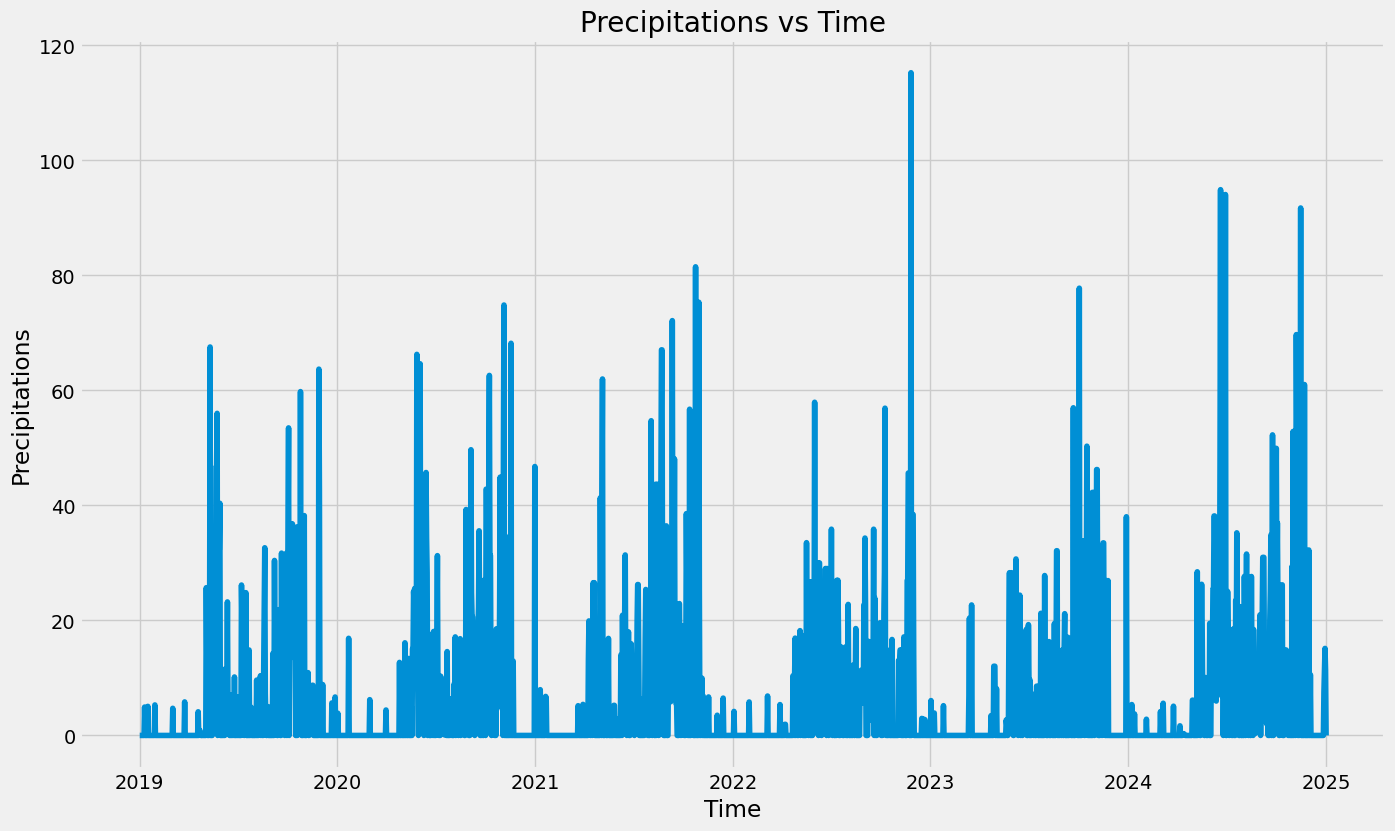

In [7]:
# Plot the precipitations around volcano
plt.figure(figsize=(15,9))
times = Rain2019_2024_df.index
precipitations = Rain2019_2024_df['Precipitations']
plt.plot(times, precipitations)
plt.title('Precipitations vs Time')
plt.xlabel('Time')
plt.ylabel('Precipitations')
plt.show()

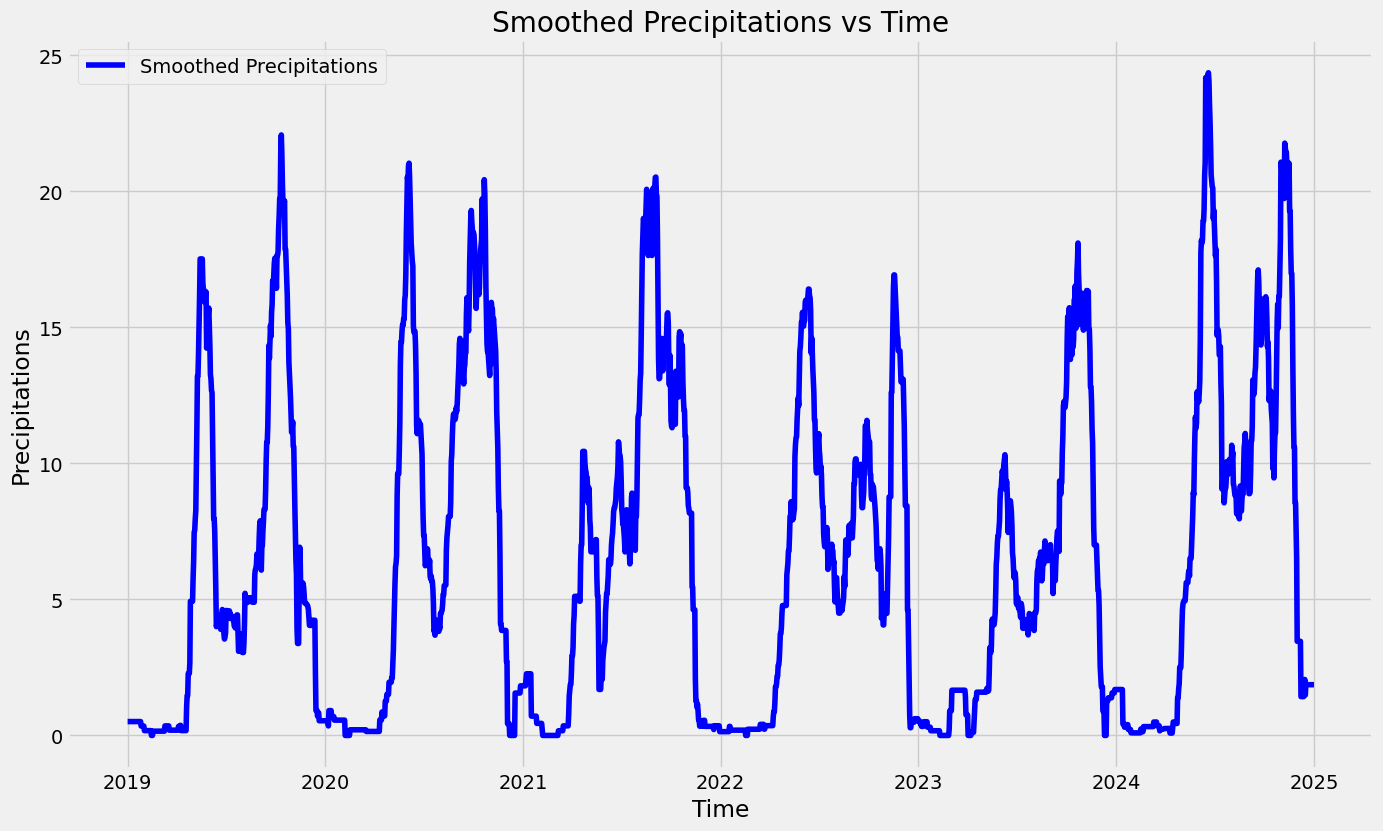

In [8]:
# Plot smoothened precipitations with a moving average

precipitations_series = pd.Series(precipitations.values, index=times)
smoothed_precipitations = precipitations_series.rolling(window=30, center=True).mean()
smoothed_precipitations = smoothed_precipitations.bfill().ffill()
plt.figure(figsize=(15,9))
plt.plot(times, smoothed_precipitations, color='blue', label='Smoothed Precipitations')
plt.title('Smoothed Precipitations vs Time')
plt.xlabel('Time')
plt.ylabel('Precipitations')
plt.legend()
plt.show()


Average precipitations during the dry season:  22.659412903225807
Average precipitations during the rainy season:  319.4603666666667


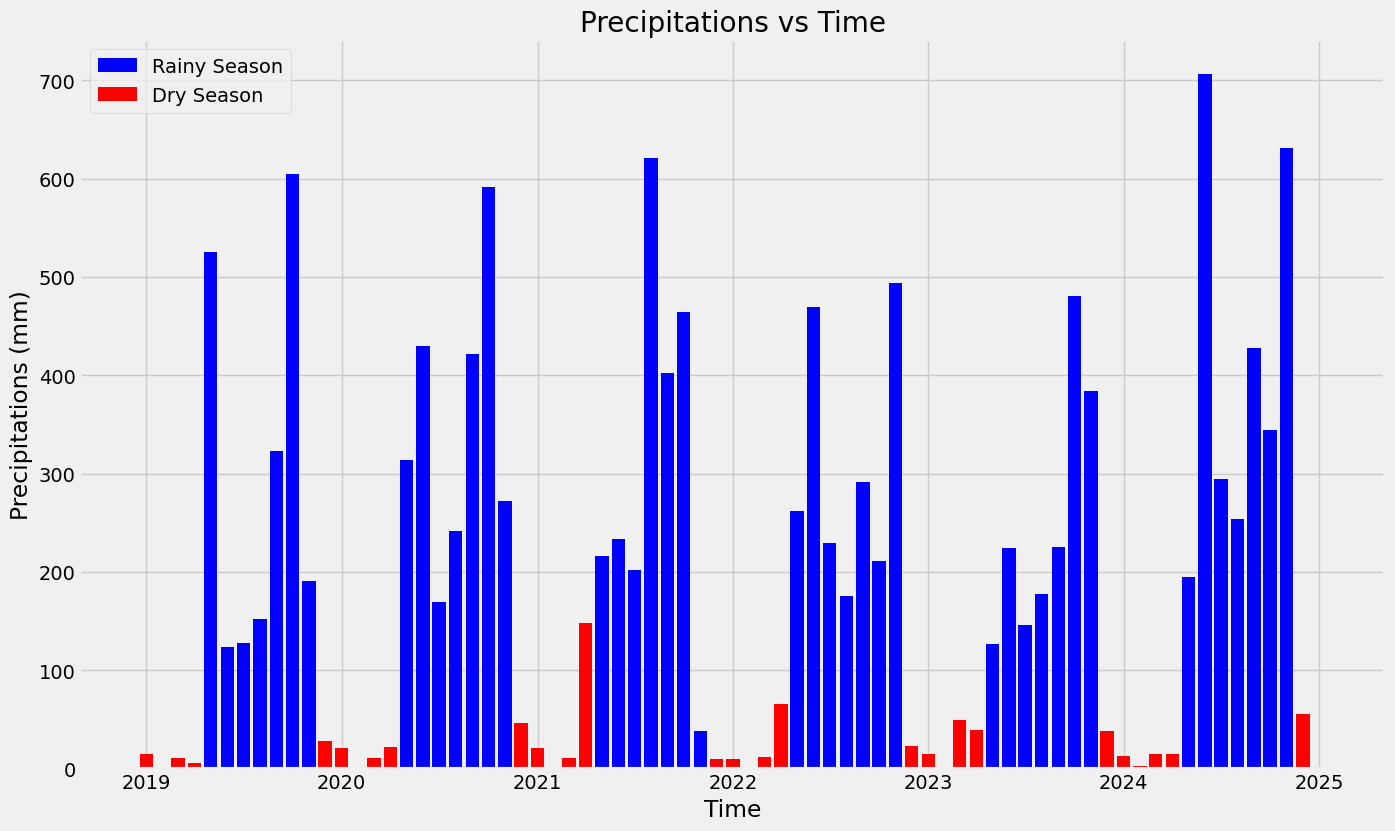

In [9]:
# Plot the precipitations distinguishing Dry and Rainy seasons
precipitations_per_month = Rain2019_2024_df.groupby(Rain2019_2024_df.index.to_period('M'))['Precipitations'].sum()
times = precipitations_per_month.index.to_timestamp()
values = precipitations_per_month.values

dry_season_months = [12, 1, 2, 3, 4]

is_dry = times.month.isin(dry_season_months)

dry_times = times[is_dry]
dry_values = values[is_dry]

rainy_times = times[~is_dry] 
rainy_values = values[~is_dry]


print("Average precipitations during the dry season: ", np.mean(dry_values))
print("Average precipitations during the rainy season: ", np.mean(rainy_values))

plt.figure(figsize=(15, 9))
plt.bar(rainy_times, rainy_values, color='blue', label='Rainy Season', width=25)
plt.bar(dry_times, dry_values, color='red', label='Dry Season', width=25)
plt.title('Precipitations vs Time')
plt.xlabel('Time')
plt.ylabel('Precipitations (mm)')
plt.legend()
plt.show()

### Lake Level Data

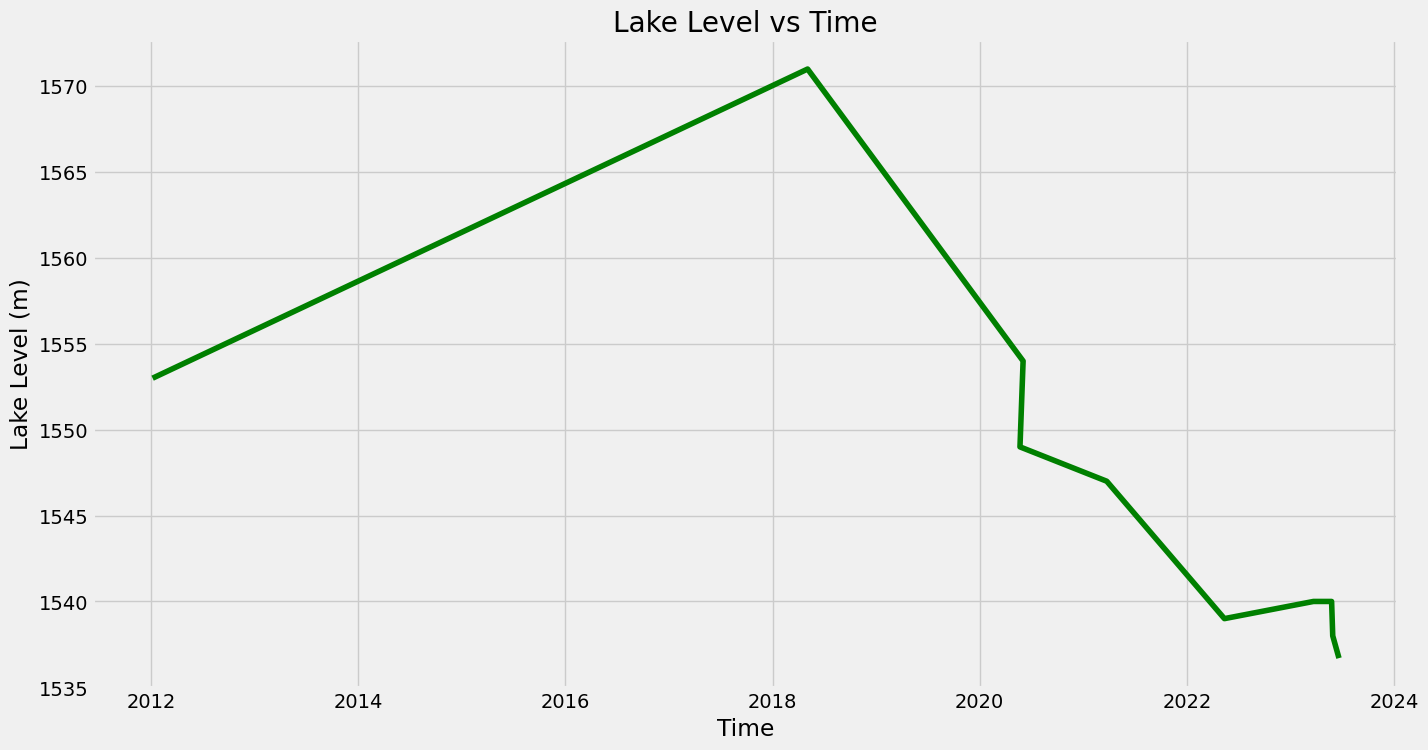

In [10]:
lake_level_df =  pd.read_csv("MSc_Bryan_Rincon/Datasets/Lake_Level.csv")
lake_level_df['Date'] = pd.to_datetime(lake_level_df['Date'], format='mixed')

plt.figure(figsize=(15, 8))
plt.plot(lake_level_df['Date'], lake_level_df['Lake_Level'], color='green')
plt.title('Lake Level vs Time')
plt.xlabel('Time')
plt.ylabel('Lake Level (m)')
plt.show()

### Lahares Data

The different informations about the Lahares are added to the global dataset.
We have the following columns:
- Eruption time: Timestamp of the eruption that triggered the lahar.
- Lahar time: Timestamp of the lahar occurrence.
- Magnitude: Magnitude of the lahar event.

In [11]:
## Add Lahares to the VRBA DataFrame
print("\nLahares DataFrame:")
Lahares_df.info()

# Drop rows + Dates in the same format
Lahares_df = Lahares_df[Lahares_df['Eruption time'].dt.year >= 2019]
vrba_minutes = VRBA_eruptions_df["t1"].dt.floor('min')
lahar_minutes = Lahares_df["Eruption time"]

# Add new column to VRBA_eruptions_df to indicate if lahar occurred
VRBA_eruptions_df["Lahares"] = vrba_minutes.isin(lahar_minutes)

# Add new eruptions where Lahares occurred but not registered
lahares_dates_not_in_VRBA = lahar_minutes[~lahar_minutes.isin(vrba_minutes)]

mag_map = Lahares_df.set_index("Eruption time")["Eruption infrasound magnitude"]

new_rows = pd.DataFrame({
    "t1": lahares_dates_not_in_VRBA,
    "Lahares": True,
    "magnitude": lahares_dates_not_in_VRBA.map(mag_map).str.replace(',', '.').astype(float)
})

VRBA_eruptions_df = pd.concat(
    [VRBA_eruptions_df, new_rows],
    ignore_index=True
)

# Add the time difference before the lahar occurred

VRBA_eruptions_df = pd.merge_asof(
    VRBA_eruptions_df.sort_values('t1'),
    Lahares_df[['Eruption time', 'Time difference (min)']].sort_values('Eruption time'),
    left_on='t1',
    right_on='Eruption time',
    direction='backward',
    tolerance=pd.Timedelta('1Min')
).rename(
    columns={'Time difference (min)': 'Time before Lahar (min)'}
).drop(columns=['Eruption time'])

print(VRBA_eruptions_df[VRBA_eruptions_df["Lahares"] == True])



Lahares DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Event                          22 non-null     int64         
 1   Eruption time                  22 non-null     datetime64[ns]
 2   Lahar time                     15 non-null     datetime64[ns]
 3   Time difference (min)          15 non-null     float64       
 4   Eruption infrasound magnitude  15 non-null     object        
dtypes: datetime64[ns](2), float64(1), int64(1), object(1)
memory usage: 1012.0+ bytes
                         t1                      t2  amplitude_max  \
0   2019-01-20 07:27:05.050 2019-01-20 07:29:11.950          5.916   
37  2020-01-30 18:13:42.427 2020-01-30 18:14:33.666          5.284   
94  2020-05-25 09:25:52.157 2020-05-25 09:26:35.065          2.599   
208 2021-06-28 11:42:04.132 2021-06-28 11:

In [12]:
lahares_dates_not_in_VRBA

11   2022-06-01 00:33:00
13   2022-01-30 19:08:00
16   2023-11-05 21:17:00
21   2023-02-06 15:05:00
Name: Eruption time, dtype: datetime64[ns]

In [13]:
print(len(VRBA_eruptions_df[VRBA_eruptions_df["Lahares"] == True]))

15


### Eruptions Data 

In [14]:
VRBA_eruptions_df.describe()

,t1,t2,amplitude_max,amplitude_rms,amplitude_p2p,energy,duration,magnitude,Time before Lahar (min)
count,971,967,967.000000,967.000000,967.000000,9.670000e+02,967.000000,971.000000,15.000000
mean,2022-08-22 19:12:35.052091648,2022-08-22 11:15:50.756762880,0.308552,0.087465,0.648961,6.259377e+05,88.527620,2.824498,20.413333
min,2019-01-20 07:27:05.050000,2019-01-20 07:29:11.950000,0.003000,0.000000,0.005000,1.482800e+01,1.247000,0.784625,8.200000
25%,2022-01-27 21:04:07.139000064,2022-01-26 15:30:29.192000,0.050000,0.015000,0.107500,2.547747e+03,25.259000,2.284488,15.000000
50%,2023-01-06 14:19:38.534000128,2023-01-06 14:20:13.998000128,0.103000,0.032000,0.225000,1.218176e+04,49.121000,2.743239,19.000000
75%,2023-08-25 02:28:58.904000,2023-08-25 02:30:54.944499968,0.247500,0.081500,0.512000,8.081618e+04,117.497500,3.293549,26.500000
max,2024-12-31 03:05:51.038000,2024-12-31 03:07:12.098000,17.436000,3.242000,28.126000,1.280676e+08,1402.151000,5.431984,32.000000
std,NaN,NaN,0.867807,0.195260,1.646017,5.145145e+06,113.641528,0.743776,7.656357


Let's see how the information of the different eruption events are distributed over time.

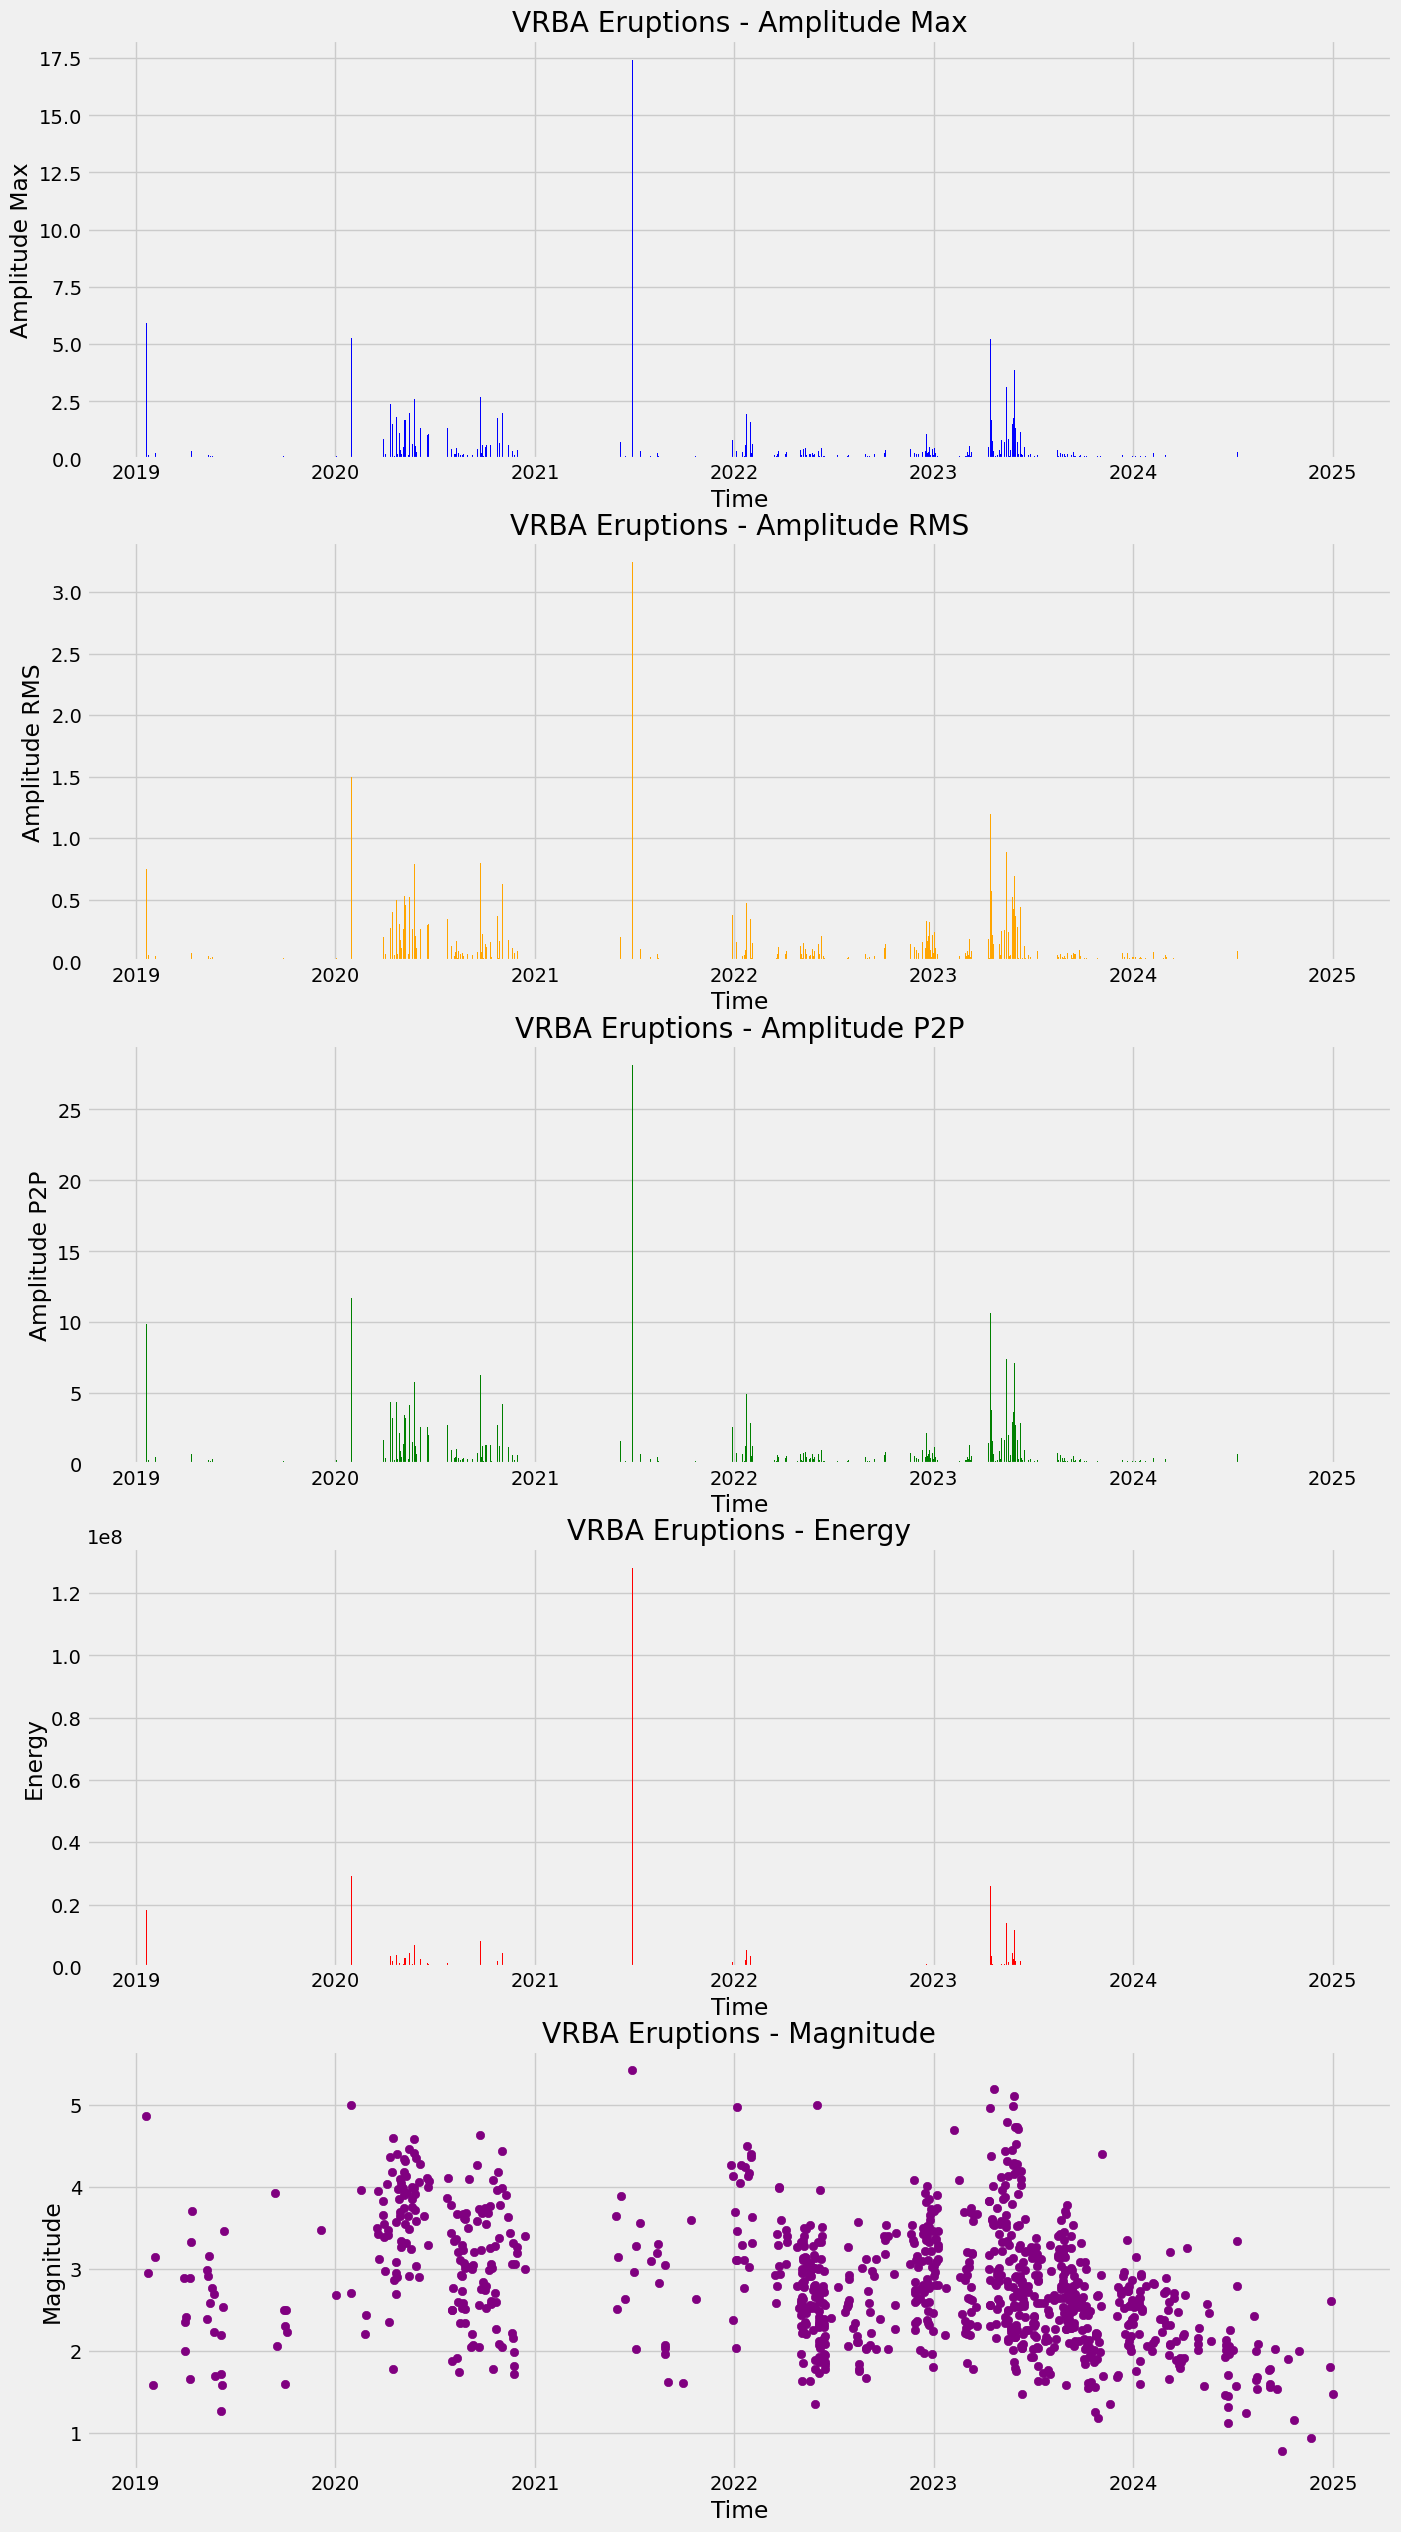

In [15]:
## Plot VRBA eruptions data

# The data is not in right order. We will sort it by t1, the start time of the eruption
VRBA_eruptions_df = VRBA_eruptions_df.sort_values(by='t1')
# # Add new columns showing the duration of the eruption
# VRBA_eruptions_df['duration'] = (VRBA_eruptions_df['t2'] - VRBA_eruptions_df['t1']).dt.total_seconds() # Duration in seconds


# Plot a bar graph of the VRBA eruptions
plt.figure(figsize=(15, 30))
plt.subplot(5, 1, 1)
plt.bar(VRBA_eruptions_df['t1'], VRBA_eruptions_df['amplitude_max'], color='blue')
plt.title('VRBA Eruptions - Amplitude Max')
plt.xlabel('Time')
plt.ylabel('Amplitude Max')
plt.subplot(5, 1, 2)
plt.bar(VRBA_eruptions_df['t1'], VRBA_eruptions_df['amplitude_rms'], color='orange')
plt.title('VRBA Eruptions - Amplitude RMS')
plt.xlabel('Time')
plt.ylabel('Amplitude RMS')
plt.subplot(5, 1, 3)
plt.bar(VRBA_eruptions_df['t1'], VRBA_eruptions_df['amplitude_p2p'], color='green')
plt.title('VRBA Eruptions - Amplitude P2P')
plt.xlabel('Time')
plt.ylabel('Amplitude P2P')
plt.subplot(5, 1, 4)
plt.bar(VRBA_eruptions_df['t1'], VRBA_eruptions_df['energy'], color='red')
plt.title('VRBA Eruptions - Energy')
plt.xlabel('Time')
plt.ylabel('Energy')
plt.subplot(5, 1, 5)
plt.scatter(VRBA_eruptions_df['t1'], VRBA_eruptions_df['magnitude'], color='purple')
plt.title('VRBA Eruptions - Magnitude')
plt.xlabel('Time')
plt.ylabel('Magnitude')
plt.show()

In [ ]:
# Percentage of eruptions per year
print(f'Percentage of eruptions in 2023: {len(VRBA_eruptions_df[VRBA_eruptions_df["t1"].dt.year == 2023]) / len(VRBA_eruptions_df) * 100:.2f}%')
print(f'Percentage of eruptions in 2022: {len(VRBA_eruptions_df[VRBA_eruptions_df["t1"].dt.year == 2022]) / len(VRBA_eruptions_df) * 100:.2f}%')
print(f'Percentage of eruptions in 2021: {len(VRBA_eruptions_df[VRBA_eruptions_df["t1"].dt.year == 2021]) / len(VRBA_eruptions_df) * 100:.2f}%')
print(f'Percentage of eruptions in 2020: {len(VRBA_eruptions_df[VRBA_eruptions_df["t1"].dt.year == 2020]) / len(VRBA_eruptions_df) * 100:.2f}%')
print(f'Percentage of eruptions in 2019: {len(VRBA_eruptions_df[VRBA_eruptions_df["t1"].dt.year == 2019]) / len(VRBA_eruptions_df) * 100:.2f}%')
print(f'Percentage of eruptions in 2024: {len(VRBA_eruptions_df[VRBA_eruptions_df["t1"].dt.year == 2024]) / len(VRBA_eruptions_df) * 100:.2f}%' )

Percentage of eruptions in 2023: 40.58%
Percentage of eruptions in 2022: 25.75%
Percentage of eruptions in 2021: 2.57%
Percentage of eruptions in 2020: 17.30%
Percentage of eruptions in 2019: 3.60%
Percentage of eruptions in 2024: 10.20%


### Continuous Measurements Data

Let's see how the Rincon de la Vieja and Rincon data are distributed over time.

####  Rincon de la Vieja Data

In [ ]:
# Filter the rsam_VORI_df and dsar_VORI_df DataFrames to keep only the data from 2019 to 2024
# rsam_VORI_df = rsam_VORI_df[(rsam_VORI_df['timestamp'] >= pd.to_datetime('2019-01-01'))&(rsam_VORI_df['timestamp'] < pd.to_datetime('2025-01-01'))]
# dsar_VORI_df = dsar_VORI_df[(dsar_VORI_df['timestamp'] >= pd.to_datetime('2019-01-01'))&(dsar_VORI_df['timestamp'] < pd.to_datetime('2025-01-01'))]

# rsam_VORI_df.to_csv('MSc_Bryan_Rincon/Datasets/rsam_VORI_2019-2025.csv', index=False)
# dsar_VORI_df.to_csv('MSc_Bryan_Rincon/Datasets/dsar_VORI_2019-2025.csv', index= False)


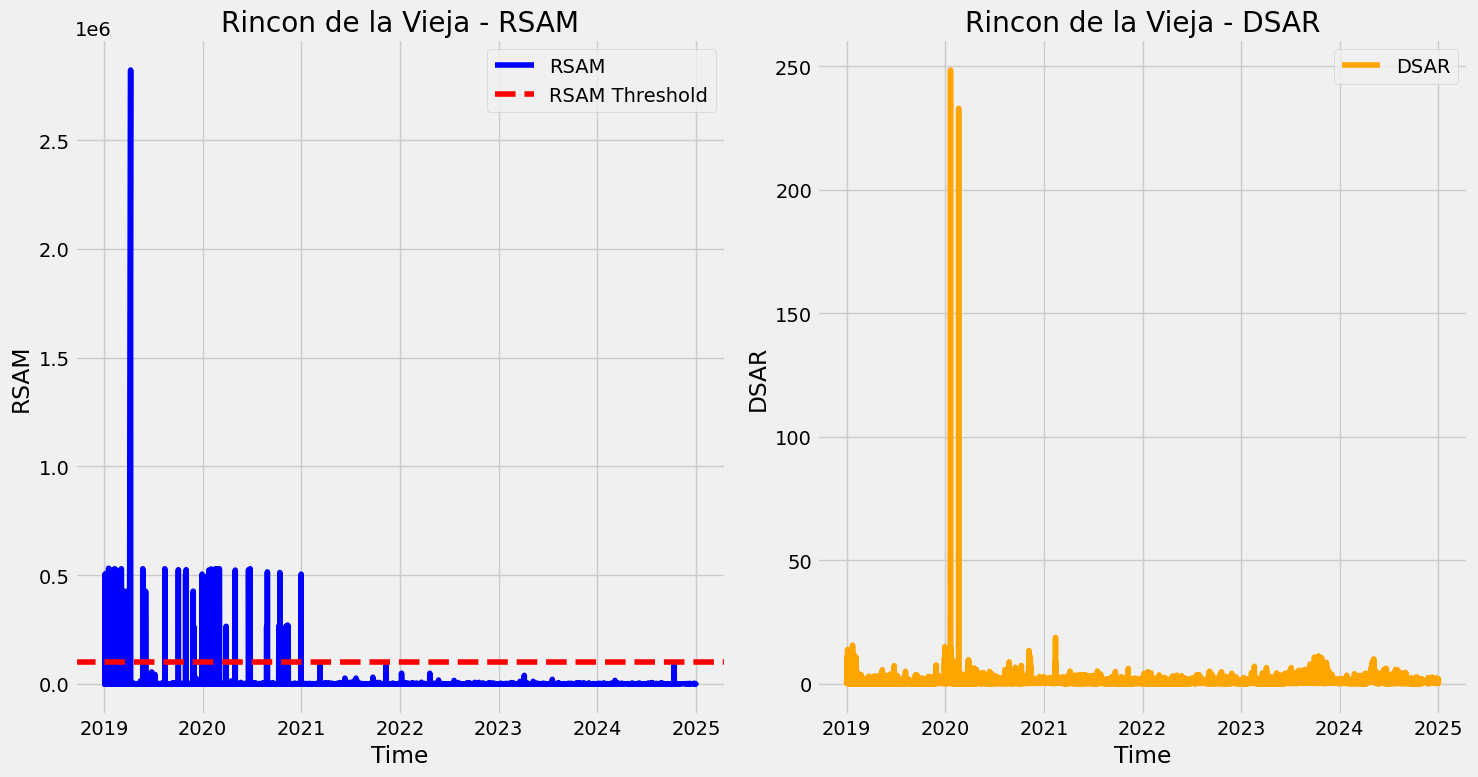

In [ ]:
## Plot data from VRBA station with RSAM graph having a threshold line at 1e5 showing the expected outliers
# [dsar , rsam, trigger  freq_bands_mean    freq_top_k    freq_index spectral_kurtosis      tonality]
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.plot(Rincon_de_la_Vieja_df.index, Rincon_de_la_Vieja_df['rsam'], label='RSAM', color='blue')
plt.axhline(y=1e5, color='red', linestyle='--', label='RSAM Threshold')

plt.title('Rincon de la Vieja - RSAM')
plt.xlabel('Time')
plt.ylabel('RSAM')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(Rincon_de_la_Vieja_df.index, Rincon_de_la_Vieja_df['dsar'], label='DSAR', color='orange')
plt.title('Rincon de la Vieja - DSAR')
plt.xlabel('Time')
plt.ylabel('DSAR')
plt.legend()
plt.tight_layout()
plt.show()

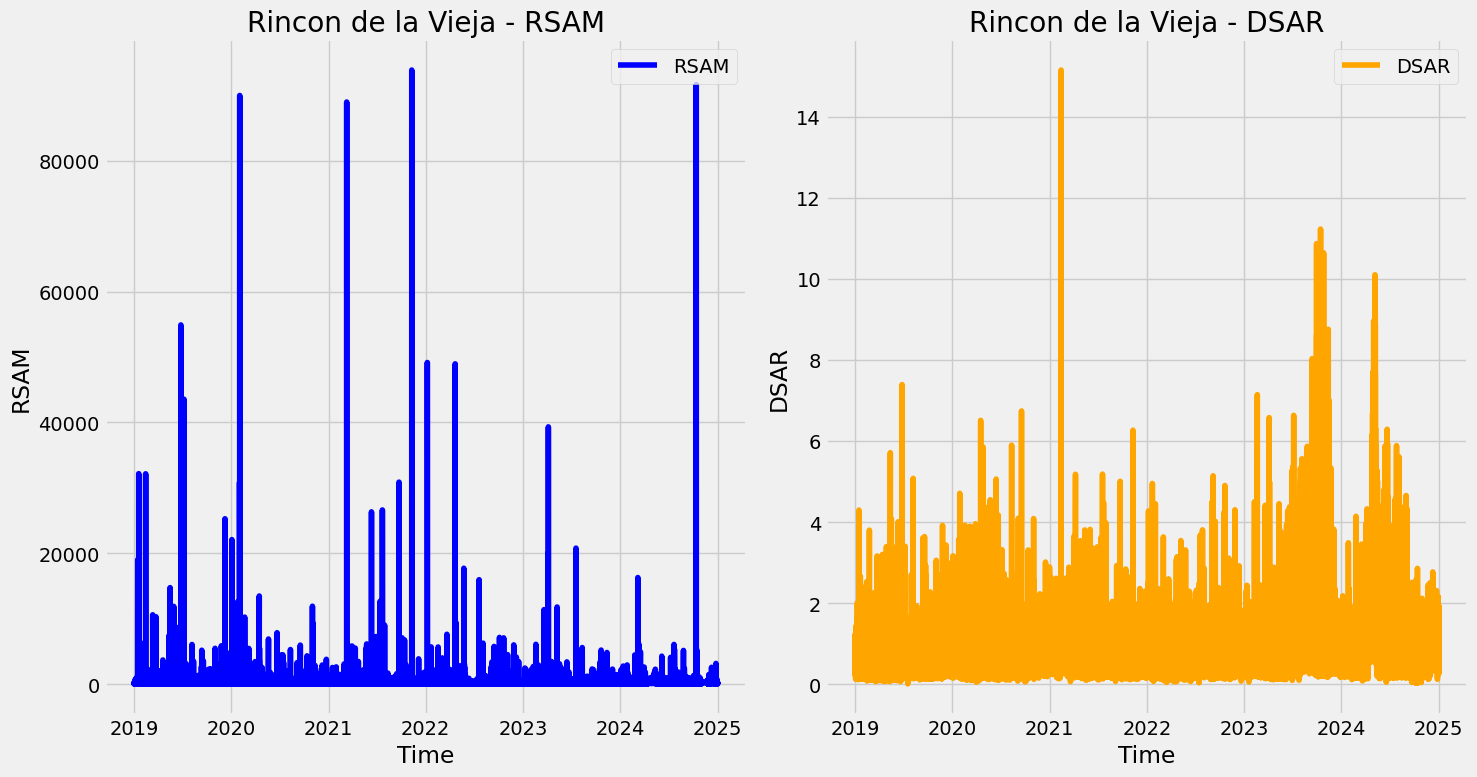

In [22]:
## Plot data with RSAM between 20 and 1e5

Rincon_de_la_Vieja_df = Rincon_de_la_Vieja_df[(20 < Rincon_de_la_Vieja_df['rsam']) & (Rincon_de_la_Vieja_df['rsam'] < 1e5)]

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.plot(Rincon_de_la_Vieja_df.index, Rincon_de_la_Vieja_df['rsam'], label='RSAM', color='blue')
plt.title('Rincon de la Vieja - RSAM')
plt.xlabel('Time')
plt.ylabel('RSAM')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(Rincon_de_la_Vieja_df.index, Rincon_de_la_Vieja_df['dsar'], label='DSAR', color='orange')
plt.title('Rincon de la Vieja - DSAR')
plt.xlabel('Time')
plt.ylabel('DSAR')
plt.legend()
plt.tight_layout()
plt.show()


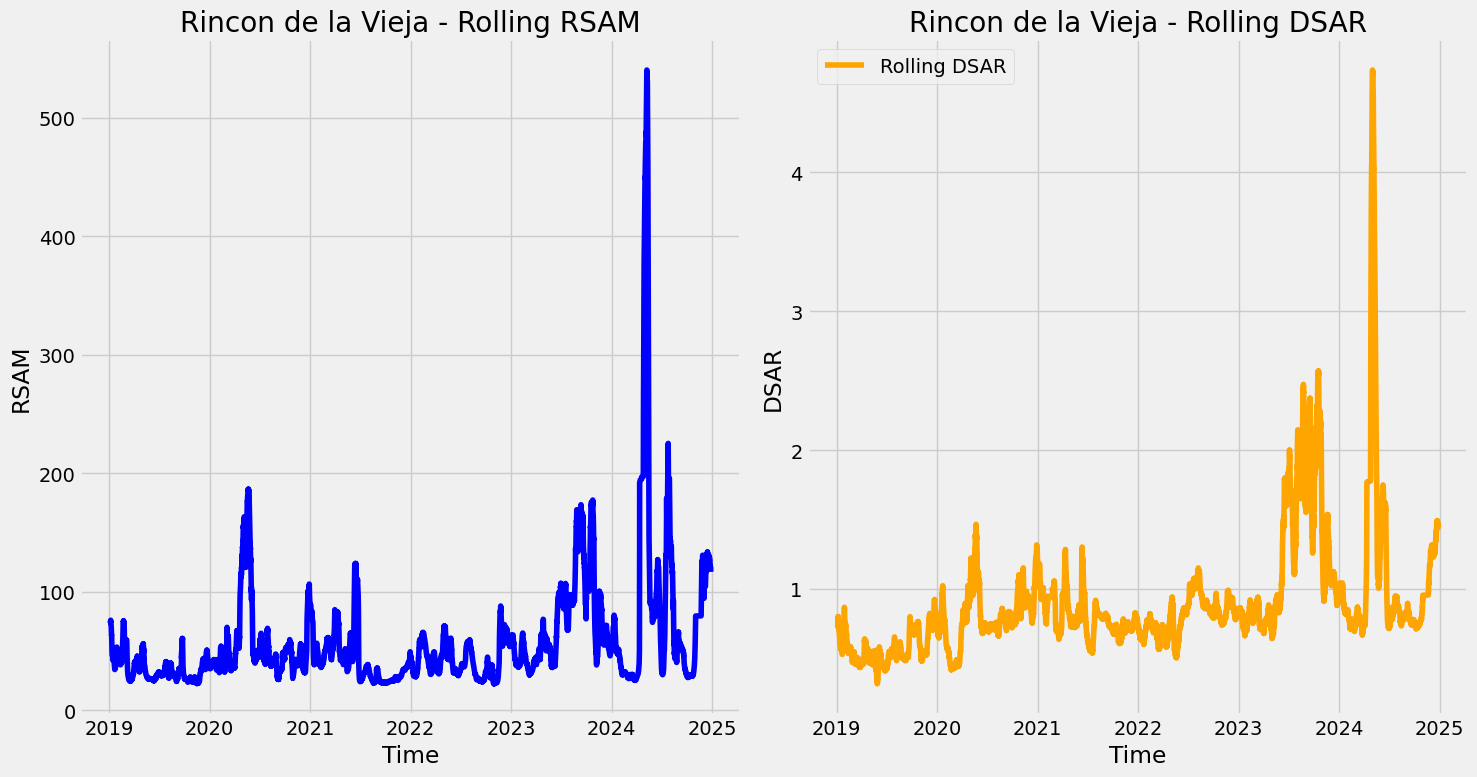

In [ ]:
## Plot of the rolling median of RSAM and DSAR with a window of 1 week and potentiel outliers removed from RSAM
rolling_rsam = Rincon_de_la_Vieja_df['rsam'].rolling(window=10080, center=True).median()
rolling_dsar = Rincon_de_la_Vieja_df['dsar'].rolling(window=10080, center=True).median()

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.plot(rolling_rsam.index, rolling_rsam.values, label='Rolling RSAM', color='blue')
plt.title('Rincon de la Vieja - Rolling RSAM')
plt.xlabel('Time')
plt.ylabel('RSAM')
plt.subplot(1, 2, 2)
plt.plot(rolling_dsar.index, rolling_dsar.values, label='Rolling DSAR', color='orange')
plt.title('Rincon de la Vieja - Rolling DSAR')
plt.xlabel('Time')
plt.ylabel('DSAR')
plt.legend()
plt.tight_layout()
plt.show()


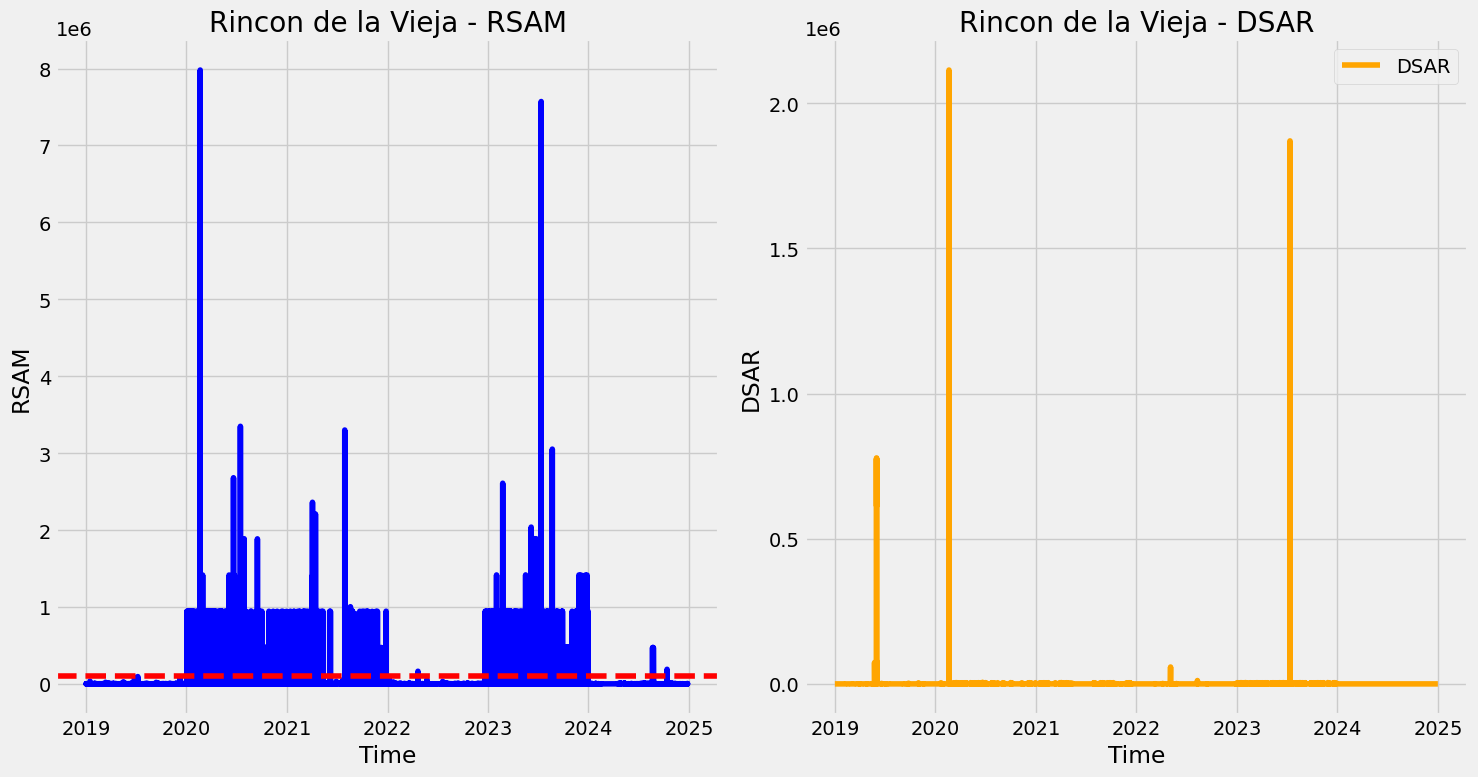

In [ ]:
## Plot data from the VORI STATION with RSAM graph having a threshold line at 1e5 showing the expected outliers
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.plot(rsam_VORI_df.index, rsam_VORI_df['value'], label='RSAM', color='blue')
plt.axhline(y=1e5, color='red', linestyle='--', label='RSAM Threshold')
plt.title('Rincon de la Vieja - RSAM')
plt.xlabel('Time')
plt.ylabel('RSAM')
plt.subplot(1, 2, 2)
plt.plot(dsar_VORI_df.index, dsar_VORI_df['value'], label='DSAR', color='orange')
plt.title('Rincon de la Vieja - DSAR')
plt.xlabel('Time')
plt.ylabel('DSAR')
plt.legend()
plt.tight_layout()
plt.show()

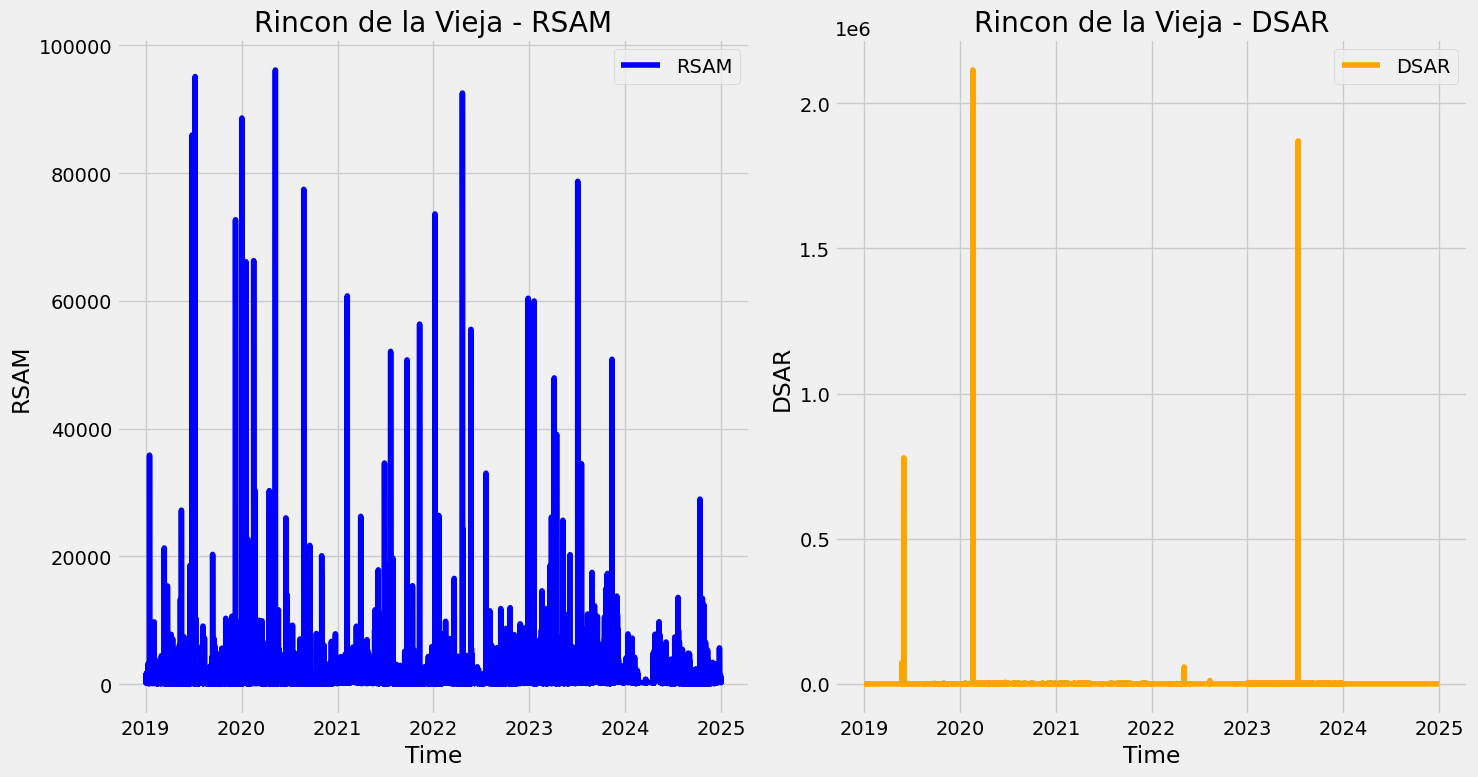

In [ ]:
# Filter the rsam_VORI_df DataFrame to keep only the data between 20 and 1e5
rsam_VORI_df = rsam_VORI_df[(20 < rsam_VORI_df['value']) & (rsam_VORI_df['value'] < 1e5)]


plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.plot(rsam_VORI_df.index, rsam_VORI_df['value'], label='RSAM', color='blue')
plt.title('Rincon de la Vieja - RSAM')
plt.xlabel('Time')
plt.ylabel('RSAM')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(dsar_VORI_df.index, dsar_VORI_df['value'], label='DSAR', color='orange')
plt.title('Rincon de la Vieja - DSAR')
plt.xlabel('Time')
plt.ylabel('DSAR')
plt.legend()
plt.tight_layout()
plt.show()

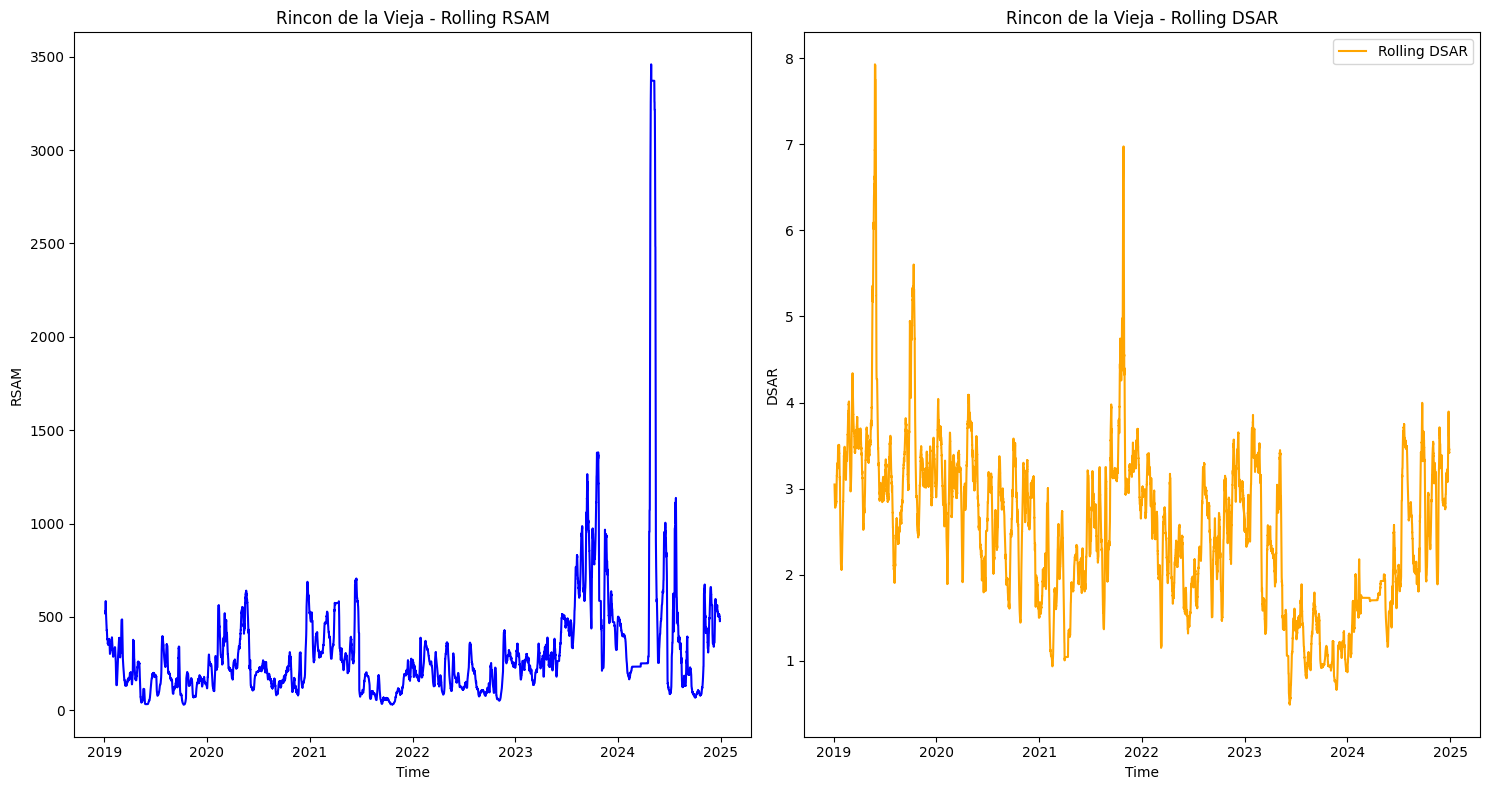

In [ ]:
# The rolling median of RSAM and DSAR with a window of 1 week and potentiel outliers removed from RSAM
rolling_rsam_vori = rsam_VORI_df['value'][(rsam_VORI_df['value']<1e5)&(rsam_VORI_df['value']>20)].rolling(window=10080, center=True).median()
rolling_dsar_vori = dsar_VORI_df['value'].rolling(window=10080, center=True).median()
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)    
plt.plot(rolling_rsam_vori.index, rolling_rsam_vori.values, label='Rolling RSAM', color='blue')
plt.title('Rincon de la Vieja - Rolling RSAM')
plt.xlabel('Time')
plt.ylabel('RSAM')
plt.subplot(1, 2, 2)
plt.plot(rolling_dsar_vori.index, rolling_dsar_vori.values, label='Rolling DSAR', color='orange')
plt.title('Rincon de la Vieja - Rolling DSAR')
plt.xlabel('Time')
plt.ylabel('DSAR')
plt.legend()
plt.tight_layout()
plt.show()


We are going to see how much data is missing in the Rincon de la Vieja continuous dataframe.

In [24]:
## Assessing missing data in Rincon de la Vieja continuous dataset


# Store the first and last time of data being recorded
# VRBA station
rsam_VRBA = Rincon_de_la_Vieja_df['rsam'][Rincon_de_la_Vieja_df['rsam'].notnull()]
dsar_VRBA = Rincon_de_la_Vieja_df['dsar'][Rincon_de_la_Vieja_df['dsar'].notnull()]
rsam_VRBA_first_time = rsam_VRBA.index.min()
dsar_VRBA_first_time = dsar_VRBA.index.min()
rsam_VRBA_last_time = rsam_VRBA.index.max() 
dsar_VRBA_last_time = dsar_VRBA.index.max()
print(f"rsam_VRBA data recorded from {rsam_VRBA_first_time} to {rsam_VRBA_last_time}")
print(f"dsar_VRBA data recorded from {dsar_VRBA_first_time} to {dsar_VRBA_last_time}")

# VORI station
rsam_VORI_first_time = rsam_VORI_df.index.min()
dsar_VORI_first_time = dsar_VORI_df.index.min()
rsam_VORI_last_time = rsam_VORI_df.index.max()
dsar_VORI_last_time = dsar_VORI_df.index.max()
print(f"rsam_VORI data recorded from {rsam_VORI_first_time} to {rsam_VORI_last_time}")
print(f"dsar_VORI data recorded from {dsar_VORI_first_time} to {dsar_VORI_last_time}")
print("\n")
# Compute the difference between the two timestamps
expected_points = (pd.to_datetime('2025-01-01') - pd.to_datetime('2019-01-01'))/pd.Timedelta('1min')

print(f" Supposed total duration of measured data: {expected_points} minutes")
print("\n")

# Calculate the actual number of data points recorded
actual_data_points0 =  rsam_VRBA.shape[0]
actual_data_points1 =  dsar_VRBA.shape[0]
actual_data_points2 = rsam_VORI_df.shape[0]
actual_data_points3 = dsar_VORI_df.shape[0]
print(f" Actual number of data points recorded for rsam_VRBA: {actual_data_points0}")# Calculate the expected number of data points for continuous recording every minute
print(f" Actual number of data points recorded for dsar_VRBA: {actual_data_points1}")
print(f" Actual number of data points recorded for rsam_VORI: {actual_data_points2}")
print(f" Actual number of data points recorded for dsar_VORI: {actual_data_points3}")
print("\n")

missing_data_points = expected_points - actual_data_points0
missing_data_points1 = expected_points - actual_data_points1
missing_data_points2 = expected_points - actual_data_points2
missing_data_points3 = expected_points - actual_data_points3
print(f" Missing data points for rsam_VRBA: {missing_data_points}")
print(f" Missing data points for dsar_VRBA: {missing_data_points1}")
print(f" Missing data points for rsam_VORI: {missing_data_points2}")
print(f" Missing data points for dsar_VORI: {missing_data_points3}")
print("\n")
# Calculate the percentage of missing data points
missing_percentage = (missing_data_points / expected_points) * 100
missing_percentage1 = (missing_data_points1 / expected_points) * 100
missing_percentage2 = (missing_data_points2 / expected_points) * 100
missing_percentage3 = (missing_data_points3 / expected_points) * 100
print(f" Percentage of missing data points for rsam_VRBA: {missing_percentage:.2f}%")
print(f" Percentage of missing data points for dsar_VRBA: {missing_percentage1:.2f}%")
print(f" Percentage of missing data points for rsam_VORI: {missing_percentage2:.2f}%")
print(f" Percentage of missing data points for dsar_VORI: {missing_percentage3:.2f}%")




rsam_VRBA data recorded from 2019-01-01 00:01:00 to 2025-01-01 00:00:00
dsar_VRBA data recorded from 2019-01-01 00:01:00 to 2025-01-01 00:00:00
rsam_VORI data recorded from 2019-01-01 00:01:00 to 2024-12-31 15:09:00
dsar_VORI data recorded from 2019-01-01 00:01:00 to 2024-12-31 15:09:00


 Supposed total duration of measured data: 3156480.0 minutes


 Actual number of data points recorded for rsam_VRBA: 2323244
 Actual number of data points recorded for dsar_VRBA: 2323244
 Actual number of data points recorded for rsam_VORI: 2869285
 Actual number of data points recorded for dsar_VORI: 2926267


 Missing data points for rsam_VRBA: 833236.0
 Missing data points for dsar_VRBA: 833236.0
 Missing data points for rsam_VORI: 287195.0
 Missing data points for dsar_VORI: 230213.0


 Percentage of missing data points for rsam_VRBA: 26.40%
 Percentage of missing data points for dsar_VRBA: 26.40%
 Percentage of missing data points for rsam_VORI: 9.10%
 Percentage of missing data points for dsar_V

We see that 26.40% of the data is missing in the Rincon de la Vieja continuous dataframe from the VRBA station. However, for the VORI station, only 9.10% of the data is missing for the rsam and 7.29% for the dsar.Let's see how the missing data points are spread over time.

In [27]:
# # Take 14 minutes to compile  ---> see csv file below

# # Copy of the time column to analyze missing data
# time_df = Rincon_de_la_Vieja_df[['time']].copy()
# # Creation of a dictionary to store missing time intervals (as key) and their counts (as value)
# min_missing = {}
# # Iterate through the time DataFrame to identify missing data points and calculating the time difference
# for i in range(1, time_df.shape[0]):
#     current_time = time_df.iloc[i]
#     previous_time = time_df.iloc[i - 1]
#     time_diff = (current_time - previous_time).dt.total_seconds().values[0] / 60  # Convert to minutes
#     if time_diff > 1:
#         if time_diff not in min_missing:
#             min_missing[time_diff] = 0
#         min_missing[time_diff] += 1
# print("\nMissing time intervals (in minutes) and their counts:")
# for interval, count in sorted(min_missing.items()):
#     print(f" {interval} minutes: {count} occurrences")

# # Store dictionary keys and values in a csv file
# missing_intervals_df = pd.DataFrame(list(min_missing.items()), columns=['Missing Interval (minutes)', 'Count'])
# missing_intervals_df.to_csv("MSc_Bryan_Rincon/Rincon_missing_intervals.csv", index=False)

# print(sum(min_missing.values()))

We have a lot of gaps in the data. There are a lot of huge gaps where data is missing till at max 20 days. Those gaps are too big to be filled with interpolation.

In [30]:
# Missing time intervals (in minutes) and their counts:
#  2.0 minutes: 148621 occurrences
#  3.0 minutes: 68946 occurrences
#  4.0 minutes: 33505 occurrences
#  5.0 minutes: 15593 occurrences
#  6.0 minutes: 7466 occurrences
#  7.0 minutes: 3834 occurrences
#  8.0 minutes: 1832 occurrences
#  9.0 minutes: 932 occurrences
#  10.0 minutes: 471 occurrences
#  11.0 minutes: 248 occurrences
#  12.0 minutes: 144 occurrences
#  13.0 minutes: 86 occurrences
#  14.0 minutes: 46 occurrences
#  15.0 minutes: 31 occurrences
#  16.0 minutes: 22 occurrences
#  17.0 minutes: 9 occurrences
#  18.0 minutes: 8 occurrences
#  19.0 minutes: 6 occurrences
#  20.0 minutes: 5 occurrences
#  21.0 minutes: 2 occurrences
#  22.0 minutes: 3 occurrences
#  23.0 minutes: 2 occurrences
#  24.0 minutes: 1 occurrences
#  25.0 minutes: 3 occurrences
#  26.0 minutes: 6 occurrences
#  27.0 minutes: 1 occurrences
#  28.0 minutes: 3 occurrences
#  29.0 minutes: 2 occurrences
#  30.0 minutes: 1 occurrences
#  31.0 minutes: 3 occurrences
#  32.0 minutes: 1 occurrences
#  33.0 minutes: 2 occurrences
#  35.0 minutes: 3 occurrences
#  37.0 minutes: 2 occurrences
#  38.0 minutes: 1 occurrences
#  39.0 minutes: 2 occurrences
#  40.0 minutes: 4 occurrences
#  41.0 minutes: 2 occurrences
#  42.0 minutes: 4 occurrences
#  43.0 minutes: 3 occurrences
#  44.0 minutes: 3 occurrences
#  46.0 minutes: 2 occurrences
#  47.0 minutes: 2 occurrences
#  48.0 minutes: 1 occurrences
#  49.0 minutes: 1 occurrences
#  50.0 minutes: 2 occurrences
#  51.0 minutes: 1 occurrences
#  52.0 minutes: 1 occurrences
#  53.0 minutes: 2 occurrences
#  55.0 minutes: 1 occurrences
#  56.0 minutes: 1 occurrences
#  57.0 minutes: 2 occurrences
#  58.0 minutes: 1 occurrences
#  60.0 minutes: 1 occurrences
#  61.0 minutes: 1 occurrences
#  63.0 minutes: 1 occurrences
#  65.0 minutes: 2 occurrences
#  67.0 minutes: 2 occurrences
#  70.0 minutes: 2 occurrences
#  71.0 minutes: 1 occurrences
#  79.0 minutes: 1 occurrences
#  80.0 minutes: 1 occurrences
#  82.0 minutes: 1 occurrences
#  84.0 minutes: 1 occurrences
#  86.0 minutes: 2 occurrences
#  87.0 minutes: 1 occurrences
#  89.0 minutes: 1 occurrences
#  92.0 minutes: 2 occurrences
#  93.0 minutes: 1 occurrences
#  95.0 minutes: 1 occurrences
#  96.0 minutes: 1 occurrences
#  101.0 minutes: 1 occurrences
#  103.0 minutes: 1 occurrences
#  106.0 minutes: 3 occurrences
#  107.0 minutes: 1 occurrences
#  108.0 minutes: 1 occurrences
#  109.0 minutes: 1 occurrences
#  111.0 minutes: 1 occurrences
#  114.0 minutes: 1 occurrences
#  117.0 minutes: 1 occurrences
#  125.0 minutes: 1 occurrences
#  126.0 minutes: 1 occurrences
#  132.0 minutes: 1 occurrences
#  137.0 minutes: 1 occurrences
#  138.0 minutes: 2 occurrences
#  141.0 minutes: 1 occurrences
#  142.0 minutes: 2 occurrences
#  145.0 minutes: 1 occurrences
#  148.0 minutes: 1 occurrences
#  153.0 minutes: 1 occurrences
#  156.0 minutes: 1 occurrences
#  159.0 minutes: 1 occurrences
#  163.0 minutes: 2 occurrences
#  170.0 minutes: 1 occurrences
#  173.0 minutes: 1 occurrences
#  175.0 minutes: 1 occurrences
#  176.0 minutes: 1 occurrences
#  186.0 minutes: 1 occurrences
#  187.0 minutes: 1 occurrences
#  190.0 minutes: 1 occurrences
#  192.0 minutes: 1 occurrences
#  199.0 minutes: 1 occurrences
#  211.0 minutes: 1 occurrences
#  213.0 minutes: 1 occurrences
#  217.0 minutes: 1 occurrences
#  218.0 minutes: 1 occurrences
#  229.0 minutes: 1 occurrences
#  238.0 minutes: 1 occurrences
#  239.0 minutes: 1 occurrences
#  247.0 minutes: 1 occurrences
#  249.0 minutes: 1 occurrences
#  265.0 minutes: 1 occurrences
#  266.0 minutes: 1 occurrences
#  275.0 minutes: 1 occurrences
#  276.0 minutes: 1 occurrences
#  283.0 minutes: 1 occurrences
#  285.0 minutes: 1 occurrences
#  290.0 minutes: 1 occurrences
#  296.0 minutes: 2 occurrences
#  301.0 minutes: 1 occurrences
#  304.0 minutes: 1 occurrences
#  322.0 minutes: 1 occurrences
#  324.0 minutes: 1 occurrences
#  331.0 minutes: 1 occurrences
#  333.0 minutes: 1 occurrences
#  337.0 minutes: 1 occurrences
#  338.0 minutes: 1 occurrences
#  339.0 minutes: 1 occurrences
#  343.0 minutes: 1 occurrences
#  346.0 minutes: 1 occurrences
#  356.0 minutes: 1 occurrences
#  358.0 minutes: 1 occurrences
#  370.0 minutes: 1 occurrences
#  381.0 minutes: 1 occurrences
#  384.0 minutes: 1 occurrences
#  390.0 minutes: 1 occurrences
#  392.0 minutes: 2 occurrences
#  410.0 minutes: 1 occurrences
#  440.0 minutes: 1 occurrences
#  450.0 minutes: 1 occurrences
#  454.0 minutes: 1 occurrences
#  459.0 minutes: 1 occurrences
#  461.0 minutes: 1 occurrences
#  518.0 minutes: 1 occurrences
#  574.0 minutes: 1 occurrences
#  584.0 minutes: 1 occurrences
#  592.0 minutes: 1 occurrences
#  625.0 minutes: 1 occurrences
#  626.0 minutes: 1 occurrences
#  635.0 minutes: 1 occurrences
#  636.0 minutes: 1 occurrences
#  644.0 minutes: 1 occurrences
#  659.0 minutes: 1 occurrences
#  760.0 minutes: 1 occurrences
#  788.0 minutes: 1 occurrences
#  812.0 minutes: 1 occurrences
#  827.0 minutes: 1 occurrences
#  837.0 minutes: 1 occurrences
#  847.0 minutes: 1 occurrences
#  864.0 minutes: 1 occurrences
#  935.0 minutes: 1 occurrences
#  1007.0 minutes: 1 occurrences
#  1012.0 minutes: 1 occurrences
#  1029.0 minutes: 1 occurrences
#  1053.0 minutes: 1 occurrences
#  1061.0 minutes: 1 occurrences
#  1212.0 minutes: 1 occurrences
#  1442.0 minutes: 2 occurrences
#  1796.0 minutes: 1 occurrences
#  2340.0 minutes: 1 occurrences
#  2575.0 minutes: 1 occurrences
#  2882.0 minutes: 1 occurrences
#  3404.0 minutes: 1 occurrences
#  4986.0 minutes: 1 occurrences
#  6122.0 minutes: 1 occurrences
#  6961.0 minutes: 1 occurrences
#  8813.0 minutes: 1 occurrences
#  28618.0 minutes: 1 occurrences

#### Rincon Data

In [25]:
Rincon_original_df.reset_index(inplace=True)

In [26]:
Rincon_original_df.columns

Index(['index', 'Fecha', 'VT', 'LP', 'Tcorto', 'Tremor', 'tfreq', 'Erupcion',
       'efreq', 'dpresion', 'Amplitud', 'Damplitud', 'sene', 'iene', 'VASR',
       'tornillo', 'Deslizamiento', 'Exhalacion'],
      dtype='object')

In [27]:
Rincon_original_df = Rincon_original_df.rename(columns={'Fecha':'time'})
Rincon_original_df = Rincon_original_df[(Rincon_original_df['time'] >= pd.to_datetime('2019-01-01')) & (Rincon_original_df['time'] < pd.to_datetime('2025-01-01')) ]
print("\nRincon DataFrame after filtering 2019-2024:")
Rincon_original_df.info()


Rincon DataFrame after filtering 2019-2024:
<class 'pandas.core.frame.DataFrame'>
Index: 2191 entries, 1826 to 4016
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   index          2191 non-null   int64         
 1   time           2191 non-null   datetime64[ns]
 2   VT             2191 non-null   float64       
 3   LP             2191 non-null   float64       
 4   Tcorto         2155 non-null   float64       
 5   Tremor         1812 non-null   float64       
 6   tfreq          992 non-null    float64       
 7   Erupcion       1588 non-null   float64       
 8   efreq          170 non-null    float64       
 9   dpresion       549 non-null    float64       
 10  Amplitud       777 non-null    float64       
 11  Damplitud      466 non-null    object        
 12  sene           187 non-null    float64       
 13  iene           181 non-null    float64       
 14  VASR           185 non-null  

There is many features missing many values. I will take only features having 100% of data of the 2191 required (2024 - 2019 in days).

In [28]:
# ## Keep only features having less than 5% missing data
# Rincon_df = Rincon_df[['time','VT', 'LP', 'tornillo']]
# Rincon_df.to_csv('MSc_Bryan_Rincon/Datasets/Rincon_2019_2024_filtered.csv', index=False)

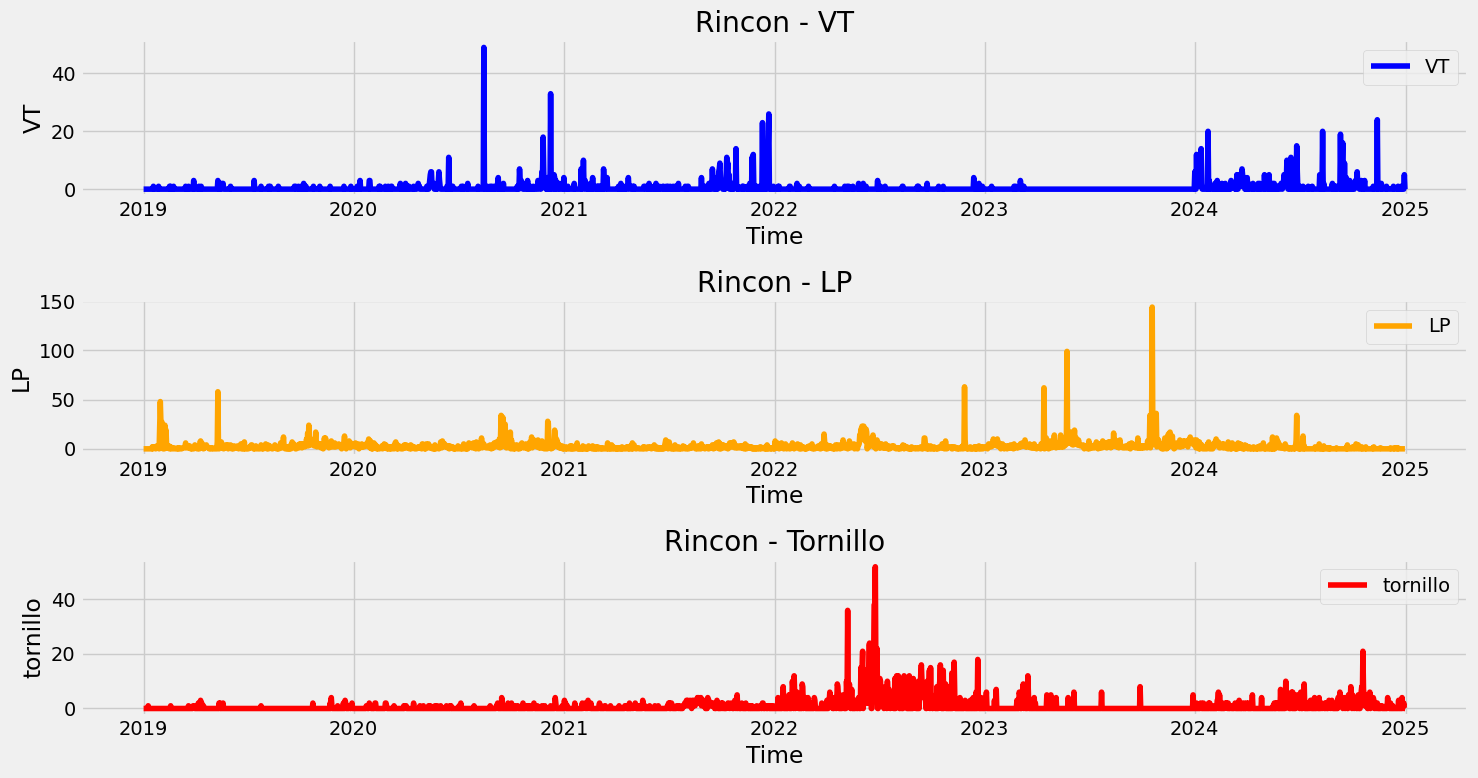

In [29]:
plt.figure(figsize=(15, 8))
plt.subplot(3, 1, 1)
plt.plot(Rincon_df.index, Rincon_df['VT'], label='VT', color='blue')
plt.title('Rincon - VT')
plt.xlabel('Time')
plt.ylabel('VT')
plt.legend()
plt.subplot(3, 1, 2)
plt.plot(Rincon_df.index, Rincon_df['LP'], label='LP', color='orange')
plt.title('Rincon - LP')
plt.xlabel('Time')
plt.ylabel('LP')
plt.legend()
plt.subplot(3, 1, 3)
plt.plot(Rincon_df.index , Rincon_df['tornillo'], label='tornillo', color='red')
plt.title('Rincon - Tornillo')
plt.xlabel('Time')
plt.ylabel('tornillo')
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# Check the date are ascending in Rincon 
for i in range(1, Rincon_df.shape[0]):
    current_time = Rincon_df.index[i]
    previous_time = Rincon_df.index[i - 1]
    if current_time < previous_time:
        print(f"Data is not in ascending order at index {i}: {current_time} < {previous_time}")

They doesnt seem to follow a specific pattern. There seems to be possible outliers . To handle them, I will apply a mean filtering technique to smooth the data and reduce their impact.

# Data preparation (features extraction,...)

## Eruption data features extraction

### Temporal Features

We can use the seasons in costa rica to categorize the eruptions in VRBA. The dry season is from December to April and the wet season is from May to November. We can create a new column in the VRBA eruptions dataframe that will tell us if the eruption happened in the dry or wet season.
https://costa-rica-guide.com/travel/weather/seasons-in-costa-rica/
Evenmore, we can extract the month and time of the day  of each eruption as new features.

In [146]:
def add_temporal_features(df):
    # 0 = Dry Season (Dec–Apr), 1 = Rainy Season (May–Nov)
    dry_months = {12, 1, 2, 3, 4}
    df = df.copy()
    df['season'] = np.where(df['t1'].dt.month.isin(dry_months), 0, 1).astype(int)

    # month feature
    df['month'] = df['t1'].dt.month
    # Cyclical month feature
    df['month norm'] = np.sin((df['t1'].dt.month - 1) * (2 * np.pi / 12))

    # time-of-day feature
    df['Time of the Day'] = df['t1'].dt.hour + df['t1'].dt.minute / 60
    # Cyclical time-of-day feature
    tod = df['t1'].dt.hour + df['t1'].dt.minute / 60
    df['Time of the Day norm'] = np.sin(tod * (2 * np.pi / 24))
    return df

# # Apply to VRBA_eruptions_df and keep season synced
VRBA_eruptions_df = add_temporal_features(VRBA_eruptions_df)
# VRBA_eruptions_df.info()
# VRBA_with_energy_category_df['season'] = VRBA_eruptions_df['season'].values

### Analysis New features

Here, as we known that the energy, amplitude rms, amplitude max, amplitude p2p, duration and magnitude are computed after the eruption occured, these features cannot be used for prediction. Thus, we will analyze the correlation of the new features (season, month, time of the day) with the laahres to see if they can be useful for prediction. But they will be used as target variables for classification models.

In [ ]:
VRBA_eruptions_df.columns

Index(['t1', 't2', 'amplitude_max', 'amplitude_rms', 'amplitude_p2p', 'energy',
       'duration', 'magnitude', 'Lahares', 'Time before Lahar (min)'],
      dtype='object')

In [ ]:
# Prepare final DataFrames for features and target

feature_columns= ['season', 'month norm', 'Time of the Day norm', 'month', 'Time of the Day']
feature_norm_columns = ['season', 'month norm', 'Time of the Day norm']

target_columns = ['Lahares','duration','amplitude_max', 'amplitude_rms', 'amplitude_p2p', 'energy_scaled', 'magnitude']
